In [ ]:
import os
import glob
import re
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel
from matplotlib.lines import Line2D

# --- Visual Configuration ---
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

plt.rcParams.update({
    "text.usetex": False,                 
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",             
    "mathtext.rm": "serif",
    "axes.labelsize": 34,
    "axes.titlesize": 30,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 20,
    "axes.titleweight": "bold"
})

# --- Label Mappings ---
LABEL_MAP = {
    'DiRoCA (epsilon_0.558_delta_0.417)': 'DiRoCA_star',
    'DiRoCA (epsilon_0.5_delta_0.5)':     'DiRoCA_0p5',
    'DiRoCA (epsilon_1.0_delta_1.0)':     'DiRoCA_1',
    'DiRoCA (epsilon_2.0_delta_2.0)':     'DiRoCA_2',
    'DiRoCA (epsilon_4.0_delta_4.0)':     'DiRoCA_4',
    'DiRoCA (epsilon_8.0_delta_8.0)':     'DiRoCA_8',
    'Gradca': 'GradCA', 'GradCA': 'GradCA',
    'Baryca': 'BARYCA', 'BaryCA': 'BARYCA',
    'Abs-LiNGAM (Perfect)': 'Abslin_p',
    'Abs-LiNGAM (Noisy)':   'Abslin_n',
}

PRINT_LABEL_MAP = {
    'DiRoCA_star': r'DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$',
    'DiRoCA_0p5':  r'DiRoCA$_{0.5,0.5}$',
    'DiRoCA_1':    r'DiRoCA$_{1,1}$',
    'DiRoCA_2':    r'DiRoCA$_{2,2}$',
    'DiRoCA_4':    r'DiRoCA$_{4,4}$',
    'DiRoCA_8':    r'DiRoCA$_{8,8}$',
    'GradCA':      r'GRAD$_{(\tau,\omega)}$',
    'BARYCA':      r'BARY$_{(\tau,\omega)}$',
    'Abslin_p':    r'AbsLin$_{\text{p}}$',
    'Abslin_n':    r'AbsLin$_{\text{n}}$',
}

# --- Color Palette ---
COLOR_MAP = {
    r'DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$': '#1f77b4', 
    r'DiRoCA$_{0.5,0.5}$': '#17becf',
    r'DiRoCA$_{1,1}$': 'gold',
    r'DiRoCA$_{2,2}$': 'darkorange',
    r'DiRoCA$_{4,4}$': 'lightskyblue',
    r'DiRoCA$_{8,8}$': 'violet',
    r'GRAD$_{(\tau,\omega)}$': '#2ca02c',                  
    r'BARY$_{(\tau,\omega)}$': '#d62728',                     
    r'AbsLin$_{\text{p}}$': '#9467bd',                       
    r'AbsLin$_{\text{n}}$': '#8c564b'                       
}

# --- Define Display Order ---
display_order = [
    r'DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$',
    r'DiRoCA$_{0.5,0.5}$', r'DiRoCA$_{1,1}$', r'DiRoCA$_{2,2}$', 
    r'DiRoCA$_{4,4}$', r'DiRoCA$_{8,8}$',
    r'GRAD$_{(\tau,\omega)}$', r'BARY$_{(\tau,\omega)}$', 
    r'AbsLin$_{\text{p}}$', r'AbsLin$_{\text{n}}$'
]

In [13]:
def load_battery_results(distribution='gaussian', shift_type='additive', base_dir="data/battery/evaluation_results"):
    pattern = os.path.join(base_dir, f"battery_eval_{shift_type}_{distribution}_*.pkl")
    files = sorted(glob.glob(pattern), key=os.path.getmtime)
    
    if not files:
        print(f"No files found for {distribution}")
        return None
        
    latest_file = files[-1]
    print(f"Loading {distribution.upper()}: {os.path.basename(latest_file)}")
    
    df = pd.read_pickle(latest_file)
    if 'method' in df.columns:
        df['method'] = df['method'].replace(LABEL_MAP)
        df['display_name'] = df['method'].map(PRINT_LABEL_MAP).fillna(df['method'])
        
    return df

def get_closest_sigma(df, target_sigma):
    sigmas = np.sort(df['noise_scale'].unique())
    idx = np.argmin(np.abs(sigmas - target_sigma))
    return sigmas[idx]

In [17]:
def plot_robustness_panel(df, distribution_name, methods_to_plot):
    if df is None: return

    # Get Max Noise and Max Alpha
    max_sigma = df['noise_scale'].max()
    max_alpha = df['alpha'].max()
    
    # Filter Data
    df_alpha_plot = df[(np.isclose(df['noise_scale'], max_sigma)) & (df['method'].isin(methods_to_plot))].copy()
    df_sigma_plot = df[(np.isclose(df['alpha'], max_alpha)) & (df['method'].isin(methods_to_plot))].copy()

    present_methods = set(df_alpha_plot['display_name'].unique()) | set(df_sigma_plot['display_name'].unique())

    fig, axes = plt.subplots(1, 2, figsize=(24, 10))
    fig.suptitle(f"{distribution_name} Noise (EBM)", fontsize=36, y=1.05)
    
    # --- Plot A: Vary Alpha ---
    ax_a = axes[0]
    sns.lineplot(
        data=df_alpha_plot, x='alpha', y='error',
        hue='display_name', hue_order=display_order, palette=COLOR_MAP,
        style='display_name', style_order=display_order,
        markers=True, dashes=False, markersize=12, linewidth=3.5,
        errorbar='sd', ax=ax_a, legend=False
    )
    
    ax_a.set_xlabel(r'$\alpha$', fontsize=34)
    ax_a.set_ylabel('Abstraction Error', fontsize=34)
    ax_a.grid(True, linestyle='--', alpha=0.7)

    # --- Plot B: Vary Sigma ---
    ax_b = axes[1]
    sns.lineplot(
        data=df_sigma_plot, x='noise_scale', y='error',
        hue='display_name', hue_order=display_order, palette=COLOR_MAP,
        style='display_name', style_order=display_order,
        markers=True, dashes=False, markersize=12, linewidth=3.5,
        errorbar='sd', ax=ax_b, legend=False
    )
    
    ax_b.set_xlabel(r'$\tilde{\sigma}$', fontsize=34)
    ax_b.set_ylabel('', fontsize=34)
    ax_b.grid(True, linestyle='--', alpha=0.7)

    legend_handles = []
    legend_labels = []
    
    for lbl in display_order:
        if lbl in present_methods:
            handle = Line2D([0], [0], color=COLOR_MAP[lbl], linewidth=3.5, marker='o', markersize=12)
            legend_handles.append(handle)
            legend_labels.append(lbl)

    if legend_handles:
        fig.legend(
            legend_handles, legend_labels,
            loc='lower center', bbox_to_anchor=(0.5, -0.15),
            ncol=5, fontsize=24, frameon=False, columnspacing=1.5
        )

    plt.tight_layout()
    plt.show()

In [18]:
def generate_stats_table(df, methods, alpha_vals=[0.0, 1.0], target_sigma=5.0):
    real_sigma = get_closest_sigma(df, target_sigma)
    print(f"\nStats for Sigma ≈ {real_sigma:.2f}")
    
    # Filter for sigma
    df_sig = df[np.isclose(df['noise_scale'], real_sigma)].copy()
    
    results = []
    
    for alpha in alpha_vals:
        df_alpha = df_sig[np.isclose(df_sig['alpha'], alpha)].copy()
        
        # Pivot
        pivot_cols = [c for c in ['fold', 'trial', 'seed'] if c in df_alpha.columns]
        paired_df = df_alpha.pivot_table(index=pivot_cols, columns='method', values='error')
        
        valid_methods = [m for m in methods if m in paired_df.columns]
        if not valid_methods: continue
            
        # 1. Find Winner
        means = paired_df[valid_methods].mean()
        winner = means.idxmin()
        
        print(f"  > Alpha={alpha}: Winner is {PRINT_LABEL_MAP.get(winner, winner)} (Err={means[winner]:.2f})")
        
        # 2. Compare
        ref_scores = paired_df[winner]
        
        for m in valid_methods:
            scores = paired_df[m]
            mean_err = scores.mean()
            std_err = scores.std()
            
            sig = ""
            if m == winner:
                sig = "--- (Ref)"
            else:
                common = ref_scores.dropna().index.intersection(scores.dropna().index)
                if len(common) > 1:
                    _, p = ttest_rel(ref_scores.loc[common], scores.loc[common])
                    if p < 0.001: sig = "***"
                    elif p < 0.01: sig = "**"
                    elif p < 0.05: sig = "*"
            
            results.append({
                "Alpha": alpha,
                "Method": PRINT_LABEL_MAP.get(m, m),
                "Error": f"{mean_err:.2f} ± {std_err:.2f}",
                "Raw_Mean": mean_err,
                "Sig.": sig
            })
            
    res_df = pd.DataFrame(results)
    for alpha in alpha_vals:
        print(f"\n--- Table: Alpha = {alpha} ---")
        sub = res_df[res_df['Alpha'] == alpha].sort_values("Raw_Mean")
        print(sub[['Method', 'Error', 'Sig.']].to_string(index=False))


ANALYSIS: GAUSSIAN NOISE
Loading GAUSSIAN: battery_eval_additive_gaussian_alpha10-0.00-1.00_noise20-0.00-10.00_trials20_20251121_150415.pkl


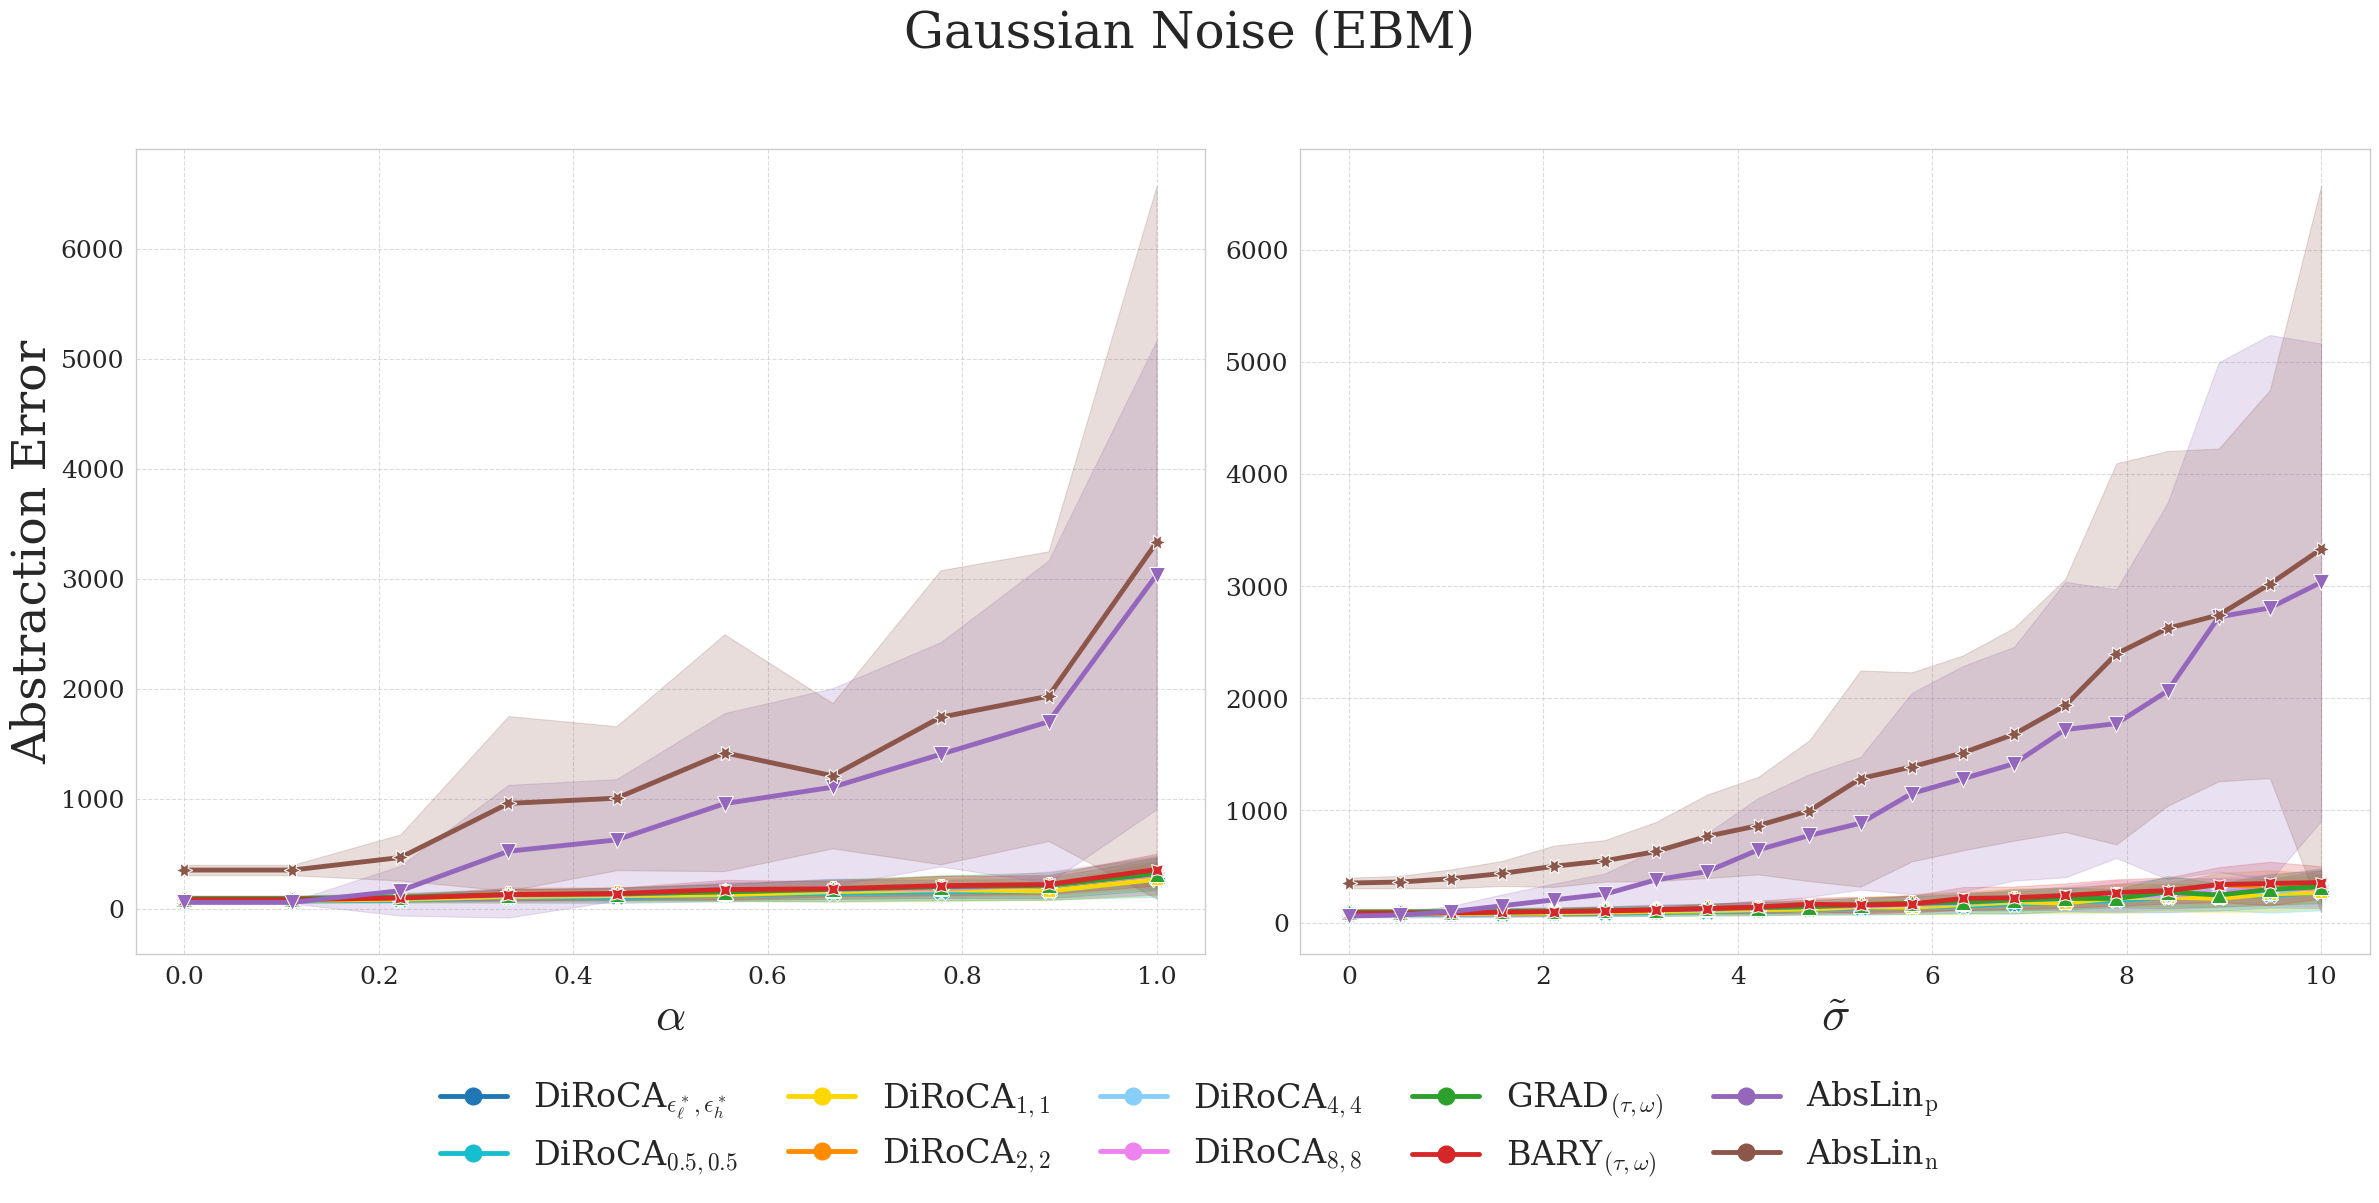


Stats for Sigma ≈ 10.00
  > Alpha=0.0: Winner is AbsLin$_{\text{p}}$ (Err=58.85)
  > Alpha=1.0: Winner is DiRoCA$_{0.5,0.5}$ (Err=268.35)

--- Table: Alpha = 0.0 ---
                                  Method          Error      Sig.
                     AbsLin$_{\text{p}}$  58.85 ± 11.27 --- (Ref)
                      DiRoCA$_{0.5,0.5}$  73.10 ± 13.12       ***
                          DiRoCA$_{1,1}$  77.80 ± 19.93       ***
DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$  83.96 ± 28.64       ***
                  BARY$_{(\tau,\omega)}$  84.03 ± 14.06       ***
                          DiRoCA$_{4,4}$  91.76 ± 27.09       ***
                          DiRoCA$_{8,8}$  91.76 ± 27.09       ***
                          DiRoCA$_{2,2}$  92.55 ± 26.11       ***
                  GRAD$_{(\tau,\omega)}$  93.53 ± 26.43       ***
                     AbsLin$_{\text{n}}$ 352.82 ± 47.07       ***

--- Table: Alpha = 1.0 ---
                                  Method             Error      Sig.
          

In [19]:
METHODS = [
    'DiRoCA_star', 'DiRoCA_0p5', 'DiRoCA_1', 'DiRoCA_2', 'DiRoCA_4', 'DiRoCA_8',
    'GradCA', 'BARYCA', 'Abslin_p', 'Abslin_n'
]

dist = 'gaussian'
print("\n" + "="*80)
print(f"ANALYSIS: {dist.upper()} NOISE")
print("="*80)

df = load_battery_results(dist)

if df is not None:
    # 1. Plots
    plot_robustness_panel(df, dist.capitalize(), METHODS)
    
    # 2. Tables (Using max sigma for worst-case)
    max_sig = df['noise_scale'].max() 
    generate_stats_table(df, METHODS, alpha_vals=[0.0, 1.0], target_sigma=max_sig)